In [28]:
import sys
sys.path.append('../')

In [29]:
from dopplerguesser.misc.curve_generator import generate_doppler_curve
from dopplerguesser.predict.observer import Observer
from dopplerguesser.predict.satellite import Satellite
import time
from matplotlib import pyplot as plt

In [30]:
ts = time.time()
TLE = """FENGYUN 2H              
1 43491U 18050A   26129.05862403 -.00000121  00000+0  00000+0 0  9996
2 43491   2.9307  79.5107 0001231 141.9043 105.9582  1.00274290 29042"""
freq = 1.7025e9

In [31]:
obs = Observer(55, 37, 200)
sat = Satellite(*TLE.splitlines(), ts)

In [32]:
dopplerdata = generate_doppler_curve(sat, obs, freq, ts, 86400, 60, simulated_noise=0)

In [33]:
dopplerdata[0:10]

[(np.int64(0), np.float64(1702499914.7811816)),
 (np.int64(60), np.float64(1702499915.136745)),
 (np.int64(120), np.float64(1702499915.4940004)),
 (np.int64(180), np.float64(1702499915.8529418)),
 (np.int64(240), np.float64(1702499916.2135627)),
 (np.int64(300), np.float64(1702499916.5758572)),
 (np.int64(360), np.float64(1702499916.9398189)),
 (np.int64(420), np.float64(1702499917.3054411)),
 (np.int64(480), np.float64(1702499917.6727178)),
 (np.int64(540), np.float64(1702499918.041643))]

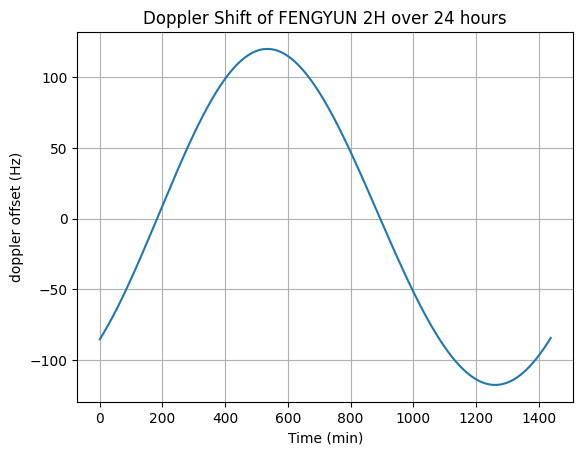

In [34]:

xvalues, yvalues = zip(*dopplerdata)
yvalues = [y - freq for y in yvalues]
xvalues = [x / 60 for x in xvalues]
plt.plot(xvalues, yvalues)
plt.xlabel("Time (min)")
plt.ylabel("doppler offset (Hz)")
plt.title(f"Doppler Shift of {sat.name.strip()} over 24 hours")
plt.grid()
plt.show()

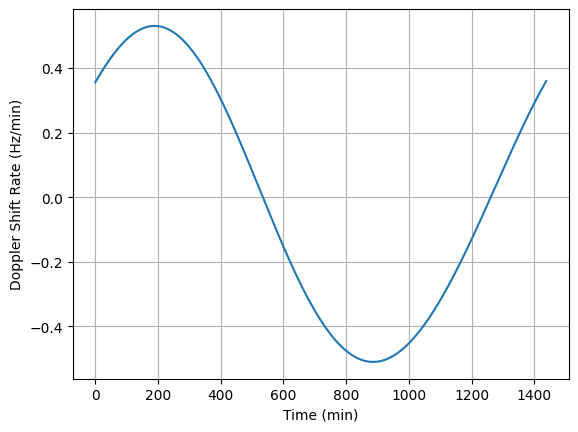

In [35]:
derivative = [(yvalues[i+1] - yvalues[i]) / (xvalues[i+1] - xvalues[i]) for i in range(len(yvalues)-1)]
plt.plot(xvalues[:-1], derivative)
plt.xlabel("Time (min)")
plt.ylabel("Doppler Shift Rate (Hz/min)")
plt.grid()
plt.show()